# RecurrentWSPR Training & Optuna Optimization

This notebook trains and optimizes the **RecurrentWSPR** model using Optuna hyperparameter tuning.

## Supported Asset Classes
- **Livestock**: LE, HE, GF (suffix: `0830_1200_2`, session end: 13:00 CST)
- **Global Commodities**: CL, NG, GC, SI, HG (suffix: `0700_1000`)

## Model Architecture
RecurrentWSPR processes data through five parallel paths:
1. **Windowed Summary**: LSTM over summary embeddings across W days
2. **Windowed Profile**: LSTM over profile embeddings across W days  
3. **Recent Raster**: RasterResNet on most recent day's rasterized VPIN
4. **Recent Sequential**: IntradayRNN on most recent day's intraday sequence
5. **Recent Spatial Fusion**: Fused profile + raster for current market state

## Optimization Strategy
- Small trial count (<20) for efficiency
- Robust parameter ranges based on prior experiments
- TPE sampler with early pruning

## 1. Environment Setup

In [19]:
# Mount Google Drive (Colab only)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print("Not running in Colab - skipping drive mount")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
# Add CTAFlow to path (Colab only)
if IN_COLAB:
    import sys
    %cd /content/drive/MyDrive/CTAEnv/
    %cd CTAFlow
    !git pull
    %cd ..
    sys.path.insert(0, '/content/drive/MyDrive/CTAEnv/CTAFlow/')
    sys.path.insert(1, '/content/drive/MyDrive/CTAEnv/SierraPy')
    !pip install -e SierraPy -q
    !pip install -e CTAFlow -q
    !pip install optuna -q
else:
    print("Running locally - ensure CTAFlow and optuna are installed")

/content/drive/MyDrive/CTAEnv
/content/drive/MyDrive/CTAEnv/CTAFlow
Already up to date.
/content/drive/MyDrive/CTAEnv
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for sierrapy (pyproject.toml) ... done


KeyboardInterrupt: 

In [ ]:
import os
import json
import warnings
from datetime import time, timedelta
from pathlib import Path
from typing import Dict, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler

warnings.filterwarnings('ignore')

print(f"PyTorch version: {torch.__version__}")
print(f"Optuna version: {optuna.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

In [ ]:
# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set seeds for reproducibility
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

## 2. Asset Class Configuration

In [ ]:
# Asset class configurations
ASSET_CONFIGS = {
    # Livestock futures
    'livestock': {
        'tickers': ['LE', 'HE'],
        'data_suffix': '0830_1200_2',
        'session_end': time(13, 0),
        'session_open': time(8, 30),
        'target_time': time(12, 30),
        'target_period': timedelta(minutes=60),
        'tz': 'America/Chicago',
    },
    # Global commodities
    'global': {
        'tickers': ['CL', 'NG', 'GC', 'SI', 'HG'],
        'data_suffix': '0700_1000_2',
        'session_end': time(14, 30),
        'session_open': time(7, 0),
        'target_time': time(14, 30),
        'target_period': timedelta(minutes=60),
        'tz': 'America/Chicago',
    },
}

# Select asset class and ticker
ASSET_CLASS = 'global'  # 'livestock' or 'global'
TICKER = 'GC'  # Select from tickers list above

config = ASSET_CONFIGS[ASSET_CLASS]
print(f"Asset Class: {ASSET_CLASS}")
print(f"Ticker: {TICKER}")
print(f"Data suffix: {config['data_suffix']}")
print(f"Session: {config['session_open']} - {config['session_end']}")
print(f"Target time: {config['target_time']}")

In [ ]:
# Path configuration
if IN_COLAB:
    DRIVE_PATH = Path('/content/drive/MyDrive')
    DATA_PATH = DRIVE_PATH / 'intraday' / 'CSV'
else:
    DRIVE_PATH = Path.cwd().parent
    DATA_PATH = DRIVE_PATH / 'data' / 'intraday'

FEATURES_PATH = DRIVE_PATH / 'features' / TICKER
RESULTS_PATH = DRIVE_PATH / 'results' / TICKER / 'wspr_optuna'
RESULTS_PATH.mkdir(parents=True, exist_ok=True)

# Build file paths based on asset class
suffix = config['data_suffix']
INTRADAY_PATH = DATA_PATH / f'{TICKER}_5min.csv'
FEATURES_FILE = FEATURES_PATH / f'{TICKER}_features_930_1h_2.csv'
SEQUENTIAL_PATH = FEATURES_PATH / f'{TICKER}_{suffix}_vpin.parquet'
PROFILE_PATH = FEATURES_PATH / f'{TICKER}_{suffix}_profiles.npz'
RASTERIZED_PATH = FEATURES_PATH / f'{TICKER}_{suffix}_rasterized_vpin.npz'
TARGET_PATH = FEATURES_PATH / f'{TICKER}_930_1030_target.csv'

print(f"\nData paths:")
print(f"  Features: {FEATURES_PATH}")
print(f"  Results: {RESULTS_PATH}")

In [ ]:
# Verify files exist
print("\nChecking data files...")
required_files = [
    (INTRADAY_PATH, "Intraday OHLCV"),
    (FEATURES_FILE, "Summary features"),
    (SEQUENTIAL_PATH, "Sequential VPIN"),
    (PROFILE_PATH, "Profile arrays"),
    (RASTERIZED_PATH, "Rasterized VPIN"),
]

missing = []
for fpath, name in required_files:
    if fpath.exists():
        print(f"  [OK] {name}")
    else:
        print(f"  [MISSING] {name}: {fpath}")
        missing.append(name)

if missing:
    print(f"\n[WARNING] {len(missing)} files missing - data loading may fail")

## 3. Load & Preprocess Data

In [ ]:
from CTAFlow.models.intraday_momentum import DeepIDMomentum, MultiModalDim

# Load data
model_data = DeepIDMomentum.from_files(
    intraday_path=str(INTRADAY_PATH),
    features_path=str(FEATURES_FILE),
    sequential_path=str(SEQUENTIAL_PATH),
    profile_path=str(PROFILE_PATH),
    rasterized_path=str(RASTERIZED_PATH),
    target_path=str(TARGET_PATH) if TARGET_PATH.exists() else None,
    target_col="target",
)

print("Data loaded successfully!")
print(f"  Summary shape: {model_data.training_data['summary'].shape}")
print(f"  Sequential shape: {model_data.sequential_data.shape}")
print(f"  Profile shape: {model_data.profile_array.shape}")
print(f"  Rasterized dates: {len(model_data.rasterized_data)}")

In [ ]:
# Task configuration
from CTAFlow.models.deep_learning.loss import OrdinalCEWithAntiCollapse as OrdinalCE, ExpectedPnLLoss as EVLoss, ProfitWeightedCE as PWCELoss, CostAwareCE

TASK = 'classification'  # 'regression' or 'classification'
NUM_CLASSES = 3

# Calculate target



model_data._calculate_target_returns(
    target_time_end=config['target_time'],
    period_length=config['target_period'],
    make_clf= (TASK == 'classification')

)

returns = model_data.target_time_returns(
    target_time= config['target_time'],
    period_length = config['target_period']
)

# Normalize features
model_data.summary_data = model_data.training_data['summary']
model_data.scale_summary_data(rolling_window=252)
model_data.normalize_sequential_features(
    scale_to_basis_points=True,
    scale_orderflow=True
)

# Get dimensions
dims = model_data.dims
print(f"\nFeature dimensions:")
print(f"  {dims}")

In [ ]:
# Visualize target distribution
if TASK == 'classification':
    fig, ax = plt.subplots(figsize=(8, 5))
    target_counts = model_data.target_data.value_counts().sort_index()
    class_weights = target_counts.values/len(model_data.target_data)
    max_weight = np.max(class_weights)
    bars = ax.bar(['Down (0)', 'Neutral (1)', 'Up (2)'][:len(target_counts)],
                  target_counts.values, color=['#e74c3c', '#95a5a6', '#27ae60'])
    ax.set_ylabel('Count')
    ax.set_title(f'{TICKER} Target Class Distribution')
    for bar, count in zip(bars, target_counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{count}\n({count/len(model_data.target_data)*100:.1f}%)',
                ha='center', va='bottom')
    plt.tight_layout()
    plt.show()
else:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(model_data.target_data.dropna(), bins=50, edgecolor='black', alpha=0.7)
    ax.axvline(0, color='red', linestyle='--', label='Zero')
    ax.set_xlabel('Return')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{TICKER} Target Return Distribution')
    ax.legend()
    plt.tight_layout()
    plt.show()

## 4. Define Optuna Objective

In [ ]:
import torch.nn.functional as F
class DistanceWeightedCELoss(nn.Module):
    """
    Penalize misclassifications more when predicted class is farther from the true class.
    Classes must be ordinal (e.g., down=0, flat=1, up=2).
    """
    def __init__(self, alpha: float = 1.0, reduction: str = "mean"):
        super().__init__()
        self.alpha = float(alpha)
        self.reduction = reduction

    def forward(self, logits: torch.Tensor, y_true: torch.Tensor) -> torch.Tensor:
        """
        logits: (B, C)
        y_true: (B,) long
        """
        ce = F.cross_entropy(logits, y_true, reduction="none")  # (B,)

        with torch.no_grad():
            y_hat = logits.argmax(dim=-1)                       # (B,)
            dist = (y_hat - y_true).abs().float()               # (B,)
            w = 1.0 + self.alpha * dist                         # (B,)

        loss = ce * w
        if self.reduction == "mean":
            return loss.mean()
        if self.reduction == "sum":
            return loss.sum()
        return loss

In [42]:
from CTAFlow.models.deep_learning.multi_branch.dual_model import RecurrentWSPR

def create_dataloaders(
    model_data,
    window_size: int,
    batch_size: int,
    val_split: float = 0.2,
):
    """Create windowed dataloaders for RecurrentWSPR."""
    train_loader, val_loader = model_data.get_loaders(
        val_split=True,
        val_split_size=val_split,
        batch_size=batch_size,
        shuffle_train=True,
        num_workers=0,
        windowed=True,
        window_days=window_size,
        use_rasterized=True,
        add_raw_returns=True,
        verbose=False,
    )
    return train_loader, val_loader


def compute_class_weights(targets: np.ndarray) -> torch.Tensor:
    """Compute inverse frequency class weights."""
    classes, counts = np.unique(targets[~np.isnan(targets)], return_counts=True)
    weights = 1.0 / counts
    weights = weights / weights.sum() * len(classes)
    return torch.tensor(weights, dtype=torch.float32)




def train_epoch(model, loader, criterion, optimizer, device, task, transaction_cost=0.0):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    total_pnl = 0.0

    for batch in loader:
        # Unpack all 7 items from your dataloader
        summary, seq, seq_lens, profile, raster, targets, raw_returns = batch

        # Move to device
        summary = summary.to(device)
        seq = seq[:, -1].to(device)
        seq_lens = seq_lens[:, -1].to(device)
        profile = profile.to(device)
        raster = raster[:, -1].to(device)
        targets = targets.to(device)
        raw_returns = raw_returns.to(device)

        if task == 'classification':
            targets = targets.long()

        optimizer.zero_grad()
        outputs = model(summary, profile, raster, seq, seq_lens)

        # --- CRITICAL CHANGE: Pass returns to ProfitWeightedCE ---
        if isinstance(criterion, ProfitWeightedCE):
            loss = criterion(outputs, targets, returns=raw_returns)
        else:
            loss = criterion(outputs, targets)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        total_samples += targets.size(0)

        if task == 'classification':
            _, predicted = outputs.max(1)
            total_correct += predicted.eq(targets).sum().item()

            # PnL tracking
            probs = torch.softmax(outputs, dim=-1)
            position = probs[:, 2] - probs[:, 0]
            pnl = position * raw_returns - transaction_cost * position.abs()
            total_pnl += pnl.sum().item()

    avg_loss = total_loss / len(loader)
    acc = 100.0 * total_correct / total_samples if total_samples > 0 else 0
    avg_pnl = total_pnl / total_samples if total_samples > 0 else 0

    return avg_loss, acc, avg_pnl

def evaluate(model,loader, criterion, device, task,transaction_cost=0.0):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    total_pnl = 0.0

    # Directional metrics
    dir_correct = 0
    dir_attempts = 0

    with torch.no_grad():
        for batch in loader:
            summary, seq, seq_lens, profile, raster, targets, raw_returns = batch

            summary = summary.to(device)
            seq = seq[:, -1].to(device)
            seq_lens = seq_lens[:, -1].to(device)
            profile = profile.to(device)
            raster = raster[:, -1].to(device)
            targets = targets.to(device)
            raw_returns = raw_returns.to(device)

            if task == 'classification':
                targets = targets.long()

            outputs = model(summary, profile, raster, seq, seq_lens)

            # --- CRITICAL CHANGE: Pass returns to ProfitWeightedCE ---
            if isinstance(criterion, ProfitWeightedCE):
                loss = criterion(outputs, targets, returns=raw_returns)
            else:
                loss = criterion(outputs, targets)

            total_loss += loss.item()
            total_samples += targets.size(0)

            if task == 'classification':
                # Accuracy & PnL
                _, predicted = outputs.max(1)
                total_correct += predicted.eq(targets).sum().item()

                probs = torch.softmax(outputs, dim=-1)
                position = probs[:, 2] - probs[:, 0]
                pnl = position * raw_returns - transaction_cost * position.abs()
                total_pnl += pnl.sum().item()

                # Directional Accuracy
                is_trade = (predicted != 1)
                if is_trade.any():
                 dir_attempts += is_trade.sum().item()



    avg_loss = total_loss / len(loader)
    max_scaled = max_weight * 100
    acc = 100.0 * total_correct / total_samples if total_samples > 0 else 0
    avg_pnl = total_pnl / total_samples if total_samples > 0 else 0
    dir_acc = (100.0 * dir_correct / dir_attempts) if dir_attempts > 0 else 0.0
    composite = avg_pnl * ((acc - max_scaled ) if acc > max_scaled else (acc / max_scaled))
    return avg_loss,avg_pnl, acc, composite, dir_acc

In [27]:
from CTAFlow.models.deep_learning.loss.clf import ProfitWeightedCE


def objective(trial: optuna.Trial) -> float:
    # --- Standard Model Hyperparameters ---
    dropout = trial.suggest_float('dropout', 0.1, 0.5)
    window_size = trial.suggest_int('window_size', 3, 15, step=3)
    d_model = trial.suggest_categorical('d_model', [32, 64])
    sum_lstm_hidden = trial.suggest_categorical('lstm_hidden', [32, 64, 128])
    prof_lstm_hidden = trial.suggest_categorical('prof_lstm', [32, 64, 128])
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
    learning_rate = trial.suggest_float('learning_rate', 5e-5, 1e-3, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-4, 1e-2, log=True)
    transaction_cost = 0.003

    # --- ProfitWeightedCE Specific Hyperparameters ---

    # 1. Profit Scale: How much do we boost the weight of high-return days?
    # Log scale is important because returns can be small (0.001) or large.
    # Higher = model cares ONLY about big moves. Lower = model cares about all moves evenly.
    profit_scale = trial.suggest_float('profit_scale', 5.0, 100.0, log=True)

    # 2. Direction Penalty: Extra punishment for getting the sign wrong.
    # 1.0 = standard penalty. 3.0 = very heavy penalty for being wrong on direction.
    direction_penalty = trial.suggest_float('direction_penalty', 1.0, 4.0)

    # 3. Min/Max Weight: Clamping to prevent exploding gradients or ignoring small days.
    # min_weight: ensures we still learn something from small chop days
    min_weight = trial.suggest_float('min_weight', 0.1, 0.5)

    # max_weight: caps the influence of a single massive outlier event
    max_weight = trial.suggest_float('max_weight', 5.0, 20.0)

    # --- Setup ---
    try:
        train_loader, val_loader = create_dataloaders(
            model_data, window_size=window_size, batch_size=batch_size, val_split=0.2
        )
    except Exception as e:
        print(f"Dataloader failed: {e}")
        return -1e9

    model = RecurrentWSPR(
        f_sum=dims.summary_dim, f_profile=dims.profile_channels, f_raster=dims.raster_channels,
        f_seq=dims.seq_dim -1, d_model=d_model, sum_lstm_hidden=sum_lstm_hidden,
        prof_lstm_hidden=prof_lstm_hidden, task=TASK, num_classes=NUM_CLASSES, dropout=dropout
    ).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

    # --- Instantiate ProfitWeightedCE ---
    if TASK == 'classification':
        criterion = ProfitWeightedCE(
            profit_scale=profit_scale,
            min_weight=min_weight,
            max_weight=max_weight,
            direction_penalty=direction_penalty
        )
    else:
        criterion = nn.MSELoss()

    # --- Training Loop ---
    best_pnl = -1e9
    patience = 10
    patience_counter = 0
    best_score = -1e9

    for epoch in range(20):
        # Pass transaction_cost if you defined it globally or suggest it
        train_loss, train_acc, _ = train_epoch(
            model, train_loader, criterion, optimizer, device, TASK, transaction_cost=transaction_cost
        )

        val_loss, val_pnl, val_acc, val_score, val_dir_acc = evaluate(
            model, val_loader, criterion, device, TASK,transaction_cost=transaction_cost
        )


        print(
            f" E{epoch+1} | "
            f"Val PnL: {val_pnl:.6f},Val Composite: {val_score}"
            f"Val Acc: {val_acc:.2f}%, Dir_acc: {val_dir_acc} "
             )
        scheduler.step()

        # Track PnL as primary metric
        if (val_score > best_score):
            best_score = val_score
            patience_counter = 0

            # Save robust metrics for post-hoc analysis
            trial.set_user_attr("final_pnl", val_pnl)
            trial.set_user_attr("final_score", val_score)
            trial.set_user_attr("final_acc", val_acc)
            trial.set_user_attr("final dir acc", val_dir_acc)
        else:
            patience_counter += 1

        trial.report(val_score, epoch)

        if trial.should_prune():
            raise optuna.TrialPruned()

        if patience_counter >= patience:
            break

    return best_score


## 5. Run Optuna Optimization

In [28]:
# Optimization settings
N_TRIALS = 30  # Keep small for efficiency
STUDY_NAME = f"{TICKER}_wspr_{TASK}"

# Create study
direction = 'maximize' if TASK == 'classification' else 'minimize'

study = optuna.create_study(
    study_name=STUDY_NAME,
    direction=direction,
    sampler=TPESampler(seed=42),
    pruner=MedianPruner(n_startup_trials=3, n_warmup_steps=5),
)

print(f"Starting optimization: {N_TRIALS} trials")
print(f"Study name: {STUDY_NAME}")
print(f"Direction: {direction}")
print(f"Task: {TASK}")
print("-" * 50)

[I 2026-01-30 21:05:05,640] A new study created in memory with name: GC_wspr_classification


Starting optimization: 30 trials
Study name: GC_wspr_classification
Direction: maximize
Task: classification
--------------------------------------------------


In [29]:
# Run optimization
study.optimize(
    objective,
    n_trials=N_TRIALS,
    show_progress_bar=True,
    gc_after_trial=True,
)

  0%|          | 0/30 [00:00<?, ?it/s]

 E1 | Val PnL: 0.364313,Val Composite: 1.4995024603771165Val Acc: 38.10%, Dir_acc: 0.0 
 E2 | Val PnL: 0.365767,Val Composite: 1.5572953740756759Val Acc: 38.24%, Dir_acc: 0.0 
 E3 | Val PnL: 0.418793,Val Composite: 1.9016968326049333Val Acc: 38.53%, Dir_acc: 0.0 
 E4 | Val PnL: 0.395464,Val Composite: 1.3476456093016502Val Acc: 37.39%, Dir_acc: 0.0 
 E5 | Val PnL: 0.445164,Val Composite: 1.3278467526578297Val Acc: 36.97%, Dir_acc: 0.0 
 E6 | Val PnL: 0.497618,Val Composite: 2.118663065405586Val Acc: 38.24%, Dir_acc: 0.0 
 E7 | Val PnL: 0.511364,Val Composite: 0.5112730551819396Val Acc: 34.99%, Dir_acc: 0.0 
 E8 | Val PnL: 0.418585,Val Composite: 1.7228846612807476Val Acc: 38.10%, Dir_acc: 0.0 
 E9 | Val PnL: 0.433344,Val Composite: 1.2925905798216355Val Acc: 36.97%, Dir_acc: 0.0 
 E10 | Val PnL: 0.484507,Val Composite: 1.307944133958307Val Acc: 36.69%, Dir_acc: 0.0 
 E11 | Val PnL: 0.373054,Val Composite: 1.4826397386163273Val Acc: 37.96%, Dir_acc: 0.0 
 E12 | Val PnL: 0.537091,Val Com

In [30]:
best_trial = study.best_trial
print(f"\nBest trial:")
trial = best_trial
print(f"  Value: {trial.value:.4f}")
print(f"  Params:")
best_params = best_trial.params
for key, value in trial.params.items():
    print(f"    {key}: {value}")

# Save best params
best_params['best_value'] = trial.value
best_params['ticker'] = TICKER
best_params['task'] = TASK

with open(RESULTS_PATH / f'{TICKER}_best_params.json', 'w') as f:
    json.dump(best_params, f, indent=2)
print(f"\nBest params saved to: {RESULTS_PATH / f'{TICKER}_best_params.json'}")


Best trial:
  Value: 3.0801
  Params:
    dropout: 0.269588828658904
    window_size: 3
    d_model: 32
    lstm_hidden: 128
    prof_lstm: 32
    batch_size: 32
    learning_rate: 0.0007162925632447043
    weight_decay: 0.002528861043027236
    profit_scale: 18.632386494600304
    direction_penalty: 3.1949655104277674
    min_weight: 0.13460677624763115
    max_weight: 17.74834615821608

Best params saved to: /content/drive/MyDrive/results/GC/wspr_optuna/GC_best_params.json


In [31]:
import joblib
import pandas as pd

def save_study_artifacts(study, filename_prefix="wspr_optuna"):
    # 1. Save the binary study object (allows resuming later)
    joblib.dump(study, RESULTS_PATH /f"{filename_prefix}_study.pkl")

    # 2. Extract all trial data to a DataFrame
    df = study.trials_dataframe()

    # 3. Clean up column names for readability
    # (Optuna prefixes params with 'params_', user_attrs with 'user_attrs_')
    df.to_csv(RESULTS_PATH / f"{filename_prefix}_all_trials.csv", index=False)

    print(f"Study saved successfully:")
    print(f"  - Object: {filename_prefix}_study.pkl")
    print(f"  - Data:   {filename_prefix}_all_trials.csv")

# Run it
save_study_artifacts(study, filename_prefix=f"{TICKER}_wspr_profit_weighted")

Study saved successfully:
  - Object: GC_wspr_profit_weighted_study.pkl
  - Data:   GC_wspr_profit_weighted_all_trials.csv


## 6. Visualization

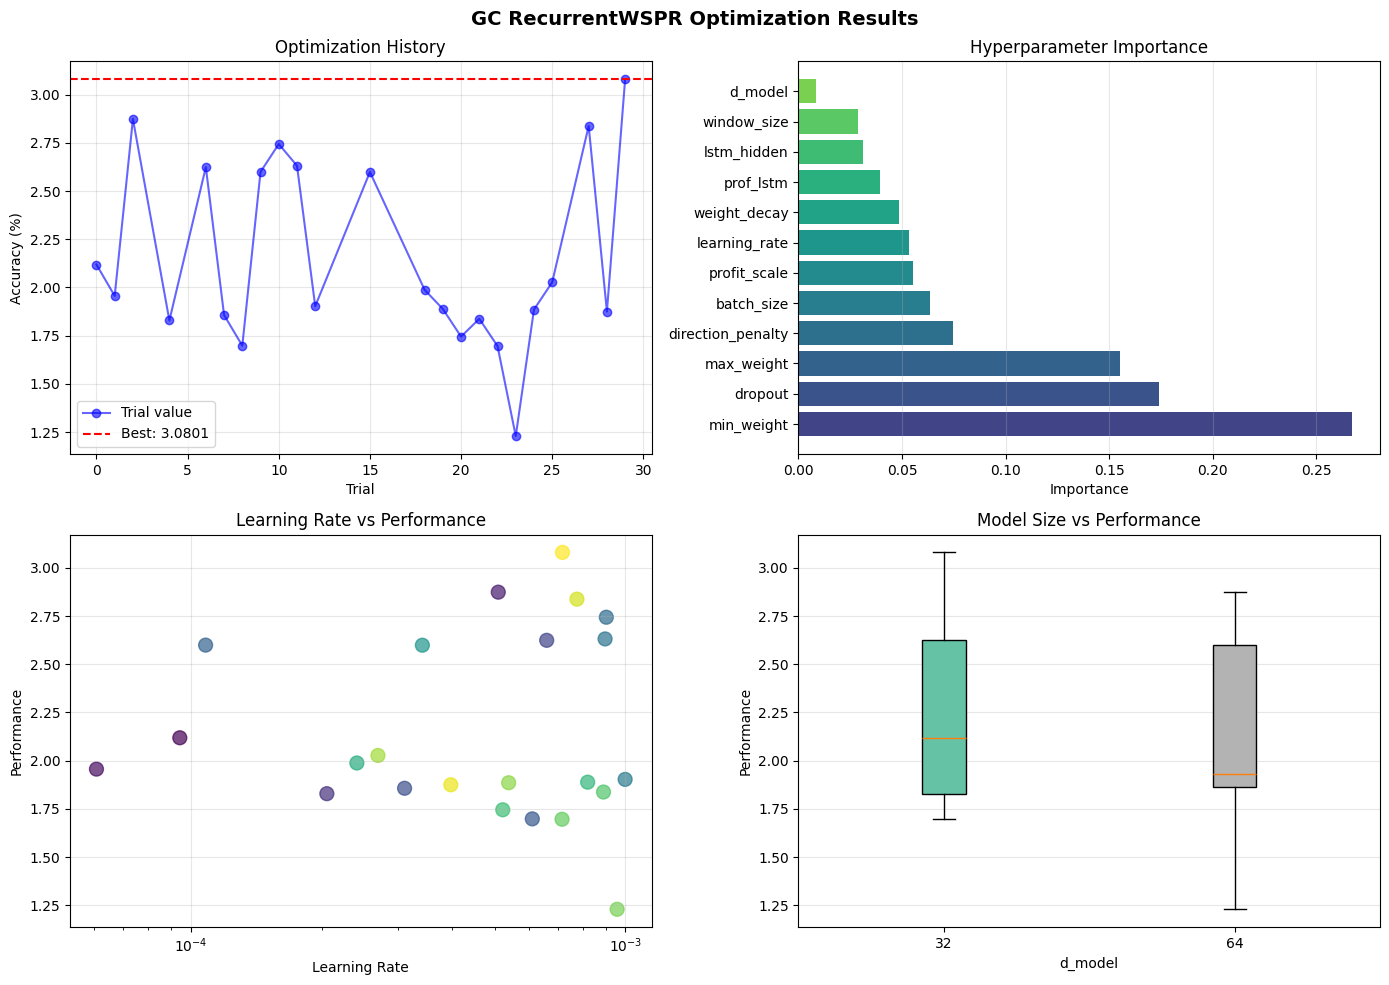

In [32]:
# Optimization history
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Optimization history
ax = axes[0, 0]
trials_df = study.trials_dataframe()
valid_trials = trials_df[trials_df['state'] == 'COMPLETE']
ax.plot(valid_trials.index, valid_trials['value'], 'b-o', alpha=0.6, label='Trial value')
ax.axhline(y=study.best_value, color='r', linestyle='--', label=f'Best: {study.best_value:.4f}')
ax.set_xlabel('Trial')
ax.set_ylabel('Accuracy (%)' if TASK == 'classification' else 'Negative MSE')
ax.set_title('Optimization History')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Parameter importance
ax = axes[0, 1]
try:
    importances = optuna.importance.get_param_importances(study)
    params = list(importances.keys())
    values = list(importances.values())
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(params)))
    bars = ax.barh(params, values, color=colors)
    ax.set_xlabel('Importance')
    ax.set_title('Hyperparameter Importance')
    ax.grid(True, alpha=0.3, axis='x')
except:
    ax.text(0.5, 0.5, 'Not enough trials\nfor importance analysis',
            ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Hyperparameter Importance')

# 3. Learning rate vs performance
ax = axes[1, 0]
if 'params_learning_rate' in valid_trials.columns:
    ax.scatter(valid_trials['params_learning_rate'], valid_trials['value'],
               c=valid_trials.index, cmap='viridis', alpha=0.7, s=100)
    ax.set_xscale('log')
    ax.set_xlabel('Learning Rate')
    ax.set_ylabel('Performance')
    ax.set_title('Learning Rate vs Performance')
    ax.grid(True, alpha=0.3)

# 4. d_model vs performance
ax = axes[1, 1]
if 'params_d_model' in valid_trials.columns:
    d_models = valid_trials['params_d_model'].unique()
    positions = range(len(d_models))
    data_by_d = [valid_trials[valid_trials['params_d_model'] == d]['value'].values for d in d_models]
    bp = ax.boxplot(data_by_d, positions=positions, patch_artist=True)
    for patch, color in zip(bp['boxes'], plt.cm.Set2(np.linspace(0, 1, len(d_models)))):
        patch.set_facecolor(color)
    ax.set_xticks(positions)
    ax.set_xticklabels([str(int(d)) for d in d_models])
    ax.set_xlabel('d_model')
    ax.set_ylabel('Performance')
    ax.set_title('Model Size vs Performance')
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle(f'{TICKER} RecurrentWSPR Optimization Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_PATH / f'{TICKER}_optimization_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Train Final Model with Best Parameters

In [33]:
# Extract best parameters
best = best_params

print("Training final model with best parameters:")
for k, v in best.items():
    print(f"  {k}: {v}")


Training final model with best parameters:
  dropout: 0.269588828658904
  window_size: 3
  d_model: 32
  lstm_hidden: 128
  prof_lstm: 32
  batch_size: 32
  learning_rate: 0.0007162925632447043
  weight_decay: 0.002528861043027236
  profit_scale: 18.632386494600304
  direction_penalty: 3.1949655104277674
  min_weight: 0.13460677624763115
  max_weight: 17.74834615821608
  best_value: 3.0801020806809345
  ticker: GC
  task: classification


In [34]:
# Create final dataloaders
train_loader, val_loader = create_dataloaders(
    model_data,
    window_size=best['window_size'],
    batch_size=best['batch_size'],
    val_split=0.2,
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Train batches: 91
Val batches: 23


In [35]:
# Create final model
final_model = RecurrentWSPR(
    f_sum=dims.summary_dim,
    f_profile=dims.profile_channels,
    f_raster=dims.raster_channels,
    f_seq=dims.seq_dim - 1,
    d_model=best['d_model'],
    sum_lstm_hidden=best['lstm_hidden'],
    prof_lstm_hidden=best['prof_lstm'],
    task=TASK,
    num_classes=NUM_CLASSES if TASK == 'classification' else 1,
    dropout=best['dropout'],
).to(device)

print(f"\nModel parameters: {sum(p.numel() for p in final_model.parameters()):,}")


Model parameters: 1,150,181


In [37]:
# Training settings
NUM_EPOCHS = 30

if TASK == 'classification':
    class_weights = compute_class_weights(model_data.target_data.values).to(device)
    criterion = ProfitWeightedCE(best['profit_scale'], best['min_weight'], best['max_weight'], best['direction_penalty'])
else:
    criterion = nn.MSELoss()

optimizer = optim.AdamW(
    final_model.parameters(),
    lr=best['learning_rate']  ,
    weight_decay=best['weight_decay']
)

scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=best['learning_rate'] * 0.001
)

# Training history
history = {
    'train_loss': [], 'val_loss': [],
    'train_metric': [], 'val_metric': [],
    'lr': []
}

best_metric = float('-inf') if TASK == 'classification' else float('inf')
best_state = None

print(f"\nStarting final training for {NUM_EPOCHS} epochs...")
print("=" * 60)


Starting final training for 30 epochs...


In [46]:
# --- FINAL TRAINING CONFIGURATION ---
# Use the params from the robust selection, or fallback to study.best_params
final_params = best_trial.params

print(f"Starting Final Training with params: {final_params}")

# 1. Setup Data with Winner's Window Size & Batch Size
train_loader, val_loader = create_dataloaders(
    model_data,
    window_size=final_params['window_size'],
    batch_size=final_params['batch_size'],
    val_split=0.2
)

# 2. Re-Initialize Model
final_model = RecurrentWSPR(
    f_sum=dims.summary_dim,
    f_profile=dims.profile_channels,
    f_raster=dims.raster_channels,
    f_seq=dims.seq_dim -1,
    d_model=final_params['d_model'],
    sum_lstm_hidden=final_params['lstm_hidden'],
    prof_lstm_hidden=final_params['prof_lstm'],
    task=TASK,
    num_classes=NUM_CLASSES,
    dropout=final_params['dropout']
).to(device)

# 3. Re-Initialize Criterion (ProfitWeightedCE)
# Check if we have the specific ProfitWeightedCE params, otherwise default
if 'profit_scale' in final_params:
    criterion = ProfitWeightedCE(
        profit_scale=final_params['profit_scale'],
        min_weight=final_params['min_weight'],
        max_weight=final_params['max_weight'],
        direction_penalty=final_params['direction_penalty']
    )
    print("Using ProfitWeightedCE for final run.")
else:
    # Fallback if you used a different loss in the study
    criterion = nn.MSELoss() if TASK == 'regression' else nn.CrossEntropyLoss()

# 4. Optimizer
optimizer = optim.AdamW(
    final_model.parameters(),
    lr=final_params['learning_rate'],
    weight_decay=final_params['weight_decay']
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=25)

# 5. Training Loop (Verbose)
best_final_pnl = -1e9
best_model_state = None

print("\nEpoch | Loss   | Acc   | PnL       | DirAcc")
print("-" * 45)

for epoch in range(25): # Fixed epoch count for final run
    train_loss, train_acc, _ = train_epoch(
        final_model, train_loader, criterion, optimizer, device, TASK, transaction_cost=0.0
    )

    val_loss,val_pnl, val_acc, val_score, val_dir_acc = evaluate(
        final_model, val_loader, criterion, device, TASK, transaction_cost=0.0
    )

    scheduler.step()

    print(f"{epoch+1:^5} | {train_loss:.4f} | {val_acc:.1f}% | {val_pnl:.6f} | {val_dir_acc:.1f}%")

    # Save state if PnL improves
    if val_pnl > best_final_pnl:
        best_final_pnl = val_pnl
        best_model_state = final_model.state_dict().copy()

# 6. Save the Best Artifact
if best_model_state:
    save_path = RESULTS_PATH / f"{TICKER}_best_robust_model.pth"
    torch.save({
        'model_state_dict': best_model_state,
        'params': final_params,
        'metrics': {'pnl': best_final_pnl, 'dir_acc': val_dir_acc}
    }, save_path)
    print(f"\nSUCCESS: Best model saved to {save_path}")
    print(f"Final Validation PnL: {best_final_pnl:.4f}")
else:
    print("\nWARNING: Model failed to achieve positive PnL in final run.")
final_model.load_state_dict(best_state)

Starting Final Training with params: {'dropout': 0.269588828658904, 'window_size': 3, 'd_model': 32, 'lstm_hidden': 128, 'prof_lstm': 32, 'batch_size': 32, 'learning_rate': 0.0007162925632447043, 'weight_decay': 0.002528861043027236, 'profit_scale': 18.632386494600304, 'direction_penalty': 3.1949655104277674, 'min_weight': 0.13460677624763115, 'max_weight': 17.74834615821608, 'best_value': 3.0801020806809345, 'ticker': 'GC', 'task': 'classification'}
Using ProfitWeightedCE for final run.

Epoch | Loss   | Acc   | PnL       | DirAcc
---------------------------------------------
  1   | 24.2922 | 39.3% | 0.280858 | 0.0%
  2   | 13.1346 | 37.9% | 0.146106 | 0.0%
  3   | 12.0276 | 39.4% | 0.254756 | 0.0%
  4   | 11.0844 | 37.9% | 0.352891 | 0.0%
  5   | 10.6490 | 35.1% | 0.486448 | 0.0%
  6   | 9.8411 | 39.0% | 0.292053 | 0.0%
  7   | 9.1404 | 38.2% | 0.265565 | 0.0%
  8   | 8.6175 | 37.9% | 0.461956 | 0.0%
  9   | 7.8430 | 37.9% | 0.404311 | 0.0%
 10   | 6.5076 | 37.2% | 0.385956 | 0.0%
 

KeyboardInterrupt: 

In [54]:
final_model.load_state_dict(best_model_state)


<All keys matched successfully>

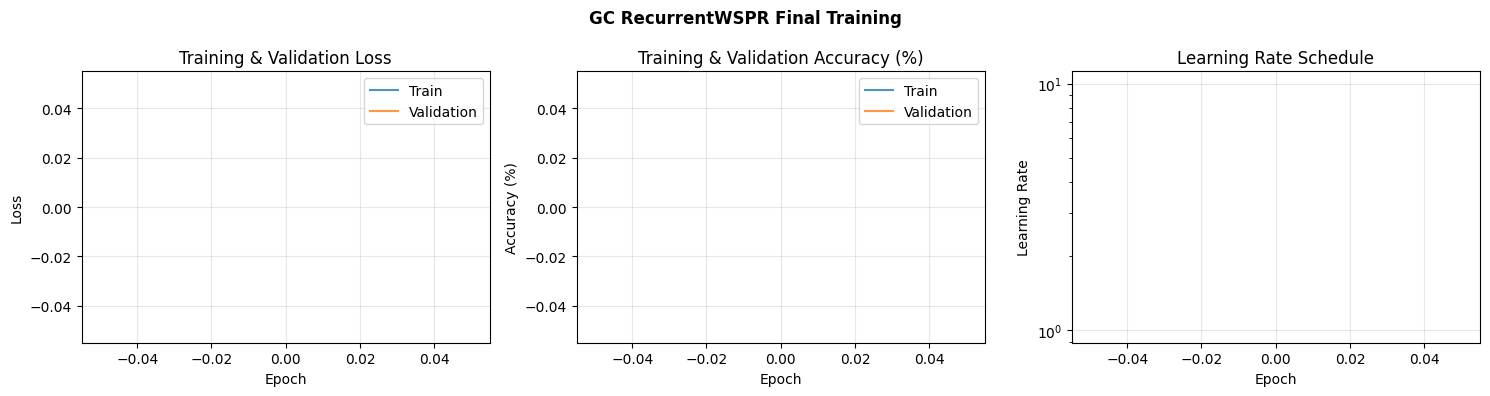

In [55]:
# Plot final training history
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
ax = axes[0]
ax.plot(history['train_loss'], label='Train', alpha=0.8)
ax.plot(history['val_loss'], label='Validation', alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training & Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# Metric
ax = axes[1]
ax.plot(history['train_metric'], label='Train', alpha=0.8)
ax.plot(history['val_metric'], label='Validation', alpha=0.8)
ax.set_xlabel('Epoch')
ylabel = 'Accuracy (%)' if TASK == 'classification' else 'Loss'
ax.set_ylabel(ylabel)
ax.set_title(f'Training & Validation {ylabel}')
ax.legend()
ax.grid(True, alpha=0.3)

# Learning rate
ax = axes[2]
ax.plot(history['lr'], 'g-', alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.set_title('Learning Rate Schedule')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

plt.suptitle(f'{TICKER} RecurrentWSPR Final Training', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_PATH / f'{TICKER}_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Final Evaluation & Predictions

In [56]:
# Collect all predictions
final_model.eval()
all_preds = []
all_targets = []
all_probs = []

with torch.no_grad():
    for batch in val_loader:
        summary_days, seq_days, seq_lens, profile_days, raster_days, targets, returns = batch

        summary_days = summary_days.to(device)
        profile_days = profile_days.to(device)
        raster_recent = raster_days[:, -1].to(device)
        seq_recent = seq_days[:, -1].to(device)
        seq_lens_recent = seq_lens[:, -1].to(device)

        outputs = final_model(summary_days, profile_days, raster_recent, seq_recent, seq_lens_recent)

        if TASK == 'classification':
            probs = torch.softmax(outputs, dim=1)
            _, preds = outputs.max(1)
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
        else:
            all_preds.extend(outputs.squeeze().cpu().numpy())

        all_targets.extend(targets.numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)
if TASK == 'classification':
    all_probs = np.array(all_probs)

print(f"Predictions: {len(all_preds)}")
print(f"Targets: {len(all_targets)}")

Predictions: 718
Targets: 718



Classification Report:
              precision    recall  f1-score   support

        Down       0.26      0.22      0.24       219
     Neutral       0.37      0.35      0.36       272
          Up       0.26      0.30      0.28       227

    accuracy                           0.30       718
   macro avg       0.29      0.29      0.29       718
weighted avg       0.30      0.30      0.30       718



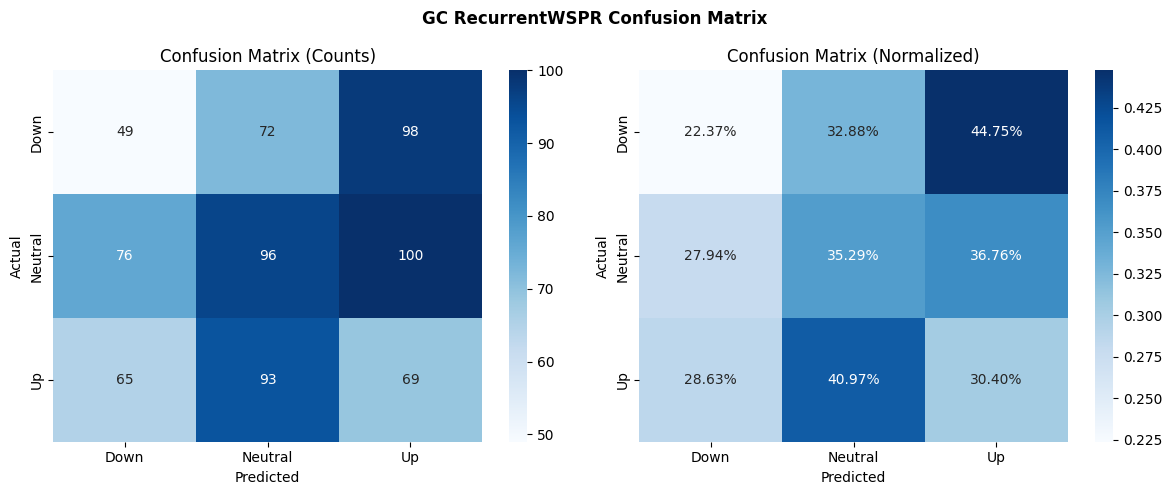

In [57]:
if TASK == 'classification':
    from sklearn.metrics import classification_report, confusion_matrix

    # Classification report
    print("\nClassification Report:")
    print("=" * 50)
    labels = ['Down', 'Neutral', 'Up'][:NUM_CLASSES]
    print(classification_report(all_targets.astype(int), all_preds, target_names=labels))

    # Confusion matrix
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Raw counts
    cm = confusion_matrix(all_targets.astype(int), all_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=labels, yticklabels=labels)
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')
    axes[0].set_title('Confusion Matrix (Counts)')

    # Normalized
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
                xticklabels=labels, yticklabels=labels)
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Actual')
    axes[1].set_title('Confusion Matrix (Normalized)')

    plt.suptitle(f'{TICKER} RecurrentWSPR Confusion Matrix', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS_PATH / f'{TICKER}_confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()

else:
    # Regression evaluation
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

    mse = mean_squared_error(all_targets, all_preds)
    mae = mean_absolute_error(all_targets, all_preds)
    r2 = r2_score(all_targets, all_preds)
    corr = np.corrcoef(all_targets, all_preds)[0, 1]

    print(f"\nRegression Metrics:")
    print(f"  MSE: {mse:.6f}")
    print(f"  MAE: {mae:.6f}")
    print(f"  R²: {r2:.4f}")
    print(f"  Correlation: {corr:.4f}")

    # Scatter plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    ax = axes[0]
    ax.scatter(all_targets, all_preds, alpha=0.5, s=20)
    lims = [min(all_preds.min()), (all_preds.max())]
    ax.plot(lims, lims, 'r--', lw=2, label='Perfect')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(f'Predictions vs Actual (Corr: {corr:.4f})')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Residuals
    ax = axes[1]
    residuals = all_preds - all_targets
    ax.hist(residuals, bins=50, edgecolor='black', alpha=0.7)
    ax.axvline(0, color='red', linestyle='--')
    ax.set_xlabel('Residual')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Residual Distribution (MAE: {mae:.6f})')
    ax.grid(True, alpha=0.3)

    plt.suptitle(f'{TICKER} RecurrentWSPR Regression Results', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS_PATH / f'{TICKER}_regression_results.png', dpi=150, bbox_inches='tight')
    plt.show()

## 9. Save Final Model

In [58]:
# Save model
model_path = RESULTS_PATH / f'{TICKER}_wspr_best.pth'
torch.save({
    'model_state_dict': final_model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'best_metric': best_metric,
    'params': best,
    'dims': {
        'summary_dim': dims.summary_dim,
        'seq_dim': dims.seq_dim,
        'profile_shape': dims.profile_shape,
        'raster_shape': dims.raster_shape,
    },
    'task': TASK,
    'num_classes': NUM_CLASSES,
}, model_path)

print(f"Model saved to: {model_path}")

# Save training history
history_df = pd.DataFrame(history)
history_df.to_csv(RESULTS_PATH / f'{TICKER}_training_history.csv', index=False)

# Summary
print(f"\n" + "=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)
print(f"\nArtifacts saved to: {RESULTS_PATH}")
print(f"  - {TICKER}_wspr_best.pth (model checkpoint)")
print(f"  - {TICKER}_best_params.json (best hyperparameters)")
print(f"  - {TICKER}_training_history.csv")
print(f"  - {TICKER}_optimization_results.png")
print(f"  - {TICKER}_training_history.png")
if TASK == 'classification':
    print(f"  - {TICKER}_confusion_matrix.png")
else:
    print(f"  - {TICKER}_regression_results.png")

Model saved to: /content/drive/MyDrive/results/GC/wspr_optuna/GC_wspr_best.pth

TRAINING COMPLETE

Artifacts saved to: /content/drive/MyDrive/results/GC/wspr_optuna
  - GC_wspr_best.pth (model checkpoint)
  - GC_best_params.json (best hyperparameters)
  - GC_training_history.csv
  - GC_optimization_results.png
  - GC_training_history.png
  - GC_confusion_matrix.png
